<a href="https://colab.research.google.com/github/RicardoMA19/Kickstarter-Campaing-Launch-Assitant/blob/main/Kickstarter-Assistant-Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Samsung Innovation Campus 2025
*Equipo 1 - "Los recaudadores"*

**Asistente inteligente de estructuración y validación de campañas de crowdfunding para la plataforma Kickstarter**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File system manangement
import os

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
kick_rawdf = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/Kickstarter Projects_639378_Aug 2025 Updated.csv', header='infer')
kick_rawdf.head(5) # solo muestra los 5 primeros datos

,collected_at,backers_count,blurb,category_id,category_name,category_parent_id,category_parent_name,category_url,converted_pledged_amount,country,...,profile_state_changed_at,project_url,spotlight,staff_pick,state,state_changed_at,static_usd_rate,usd_exchange_rate,usd_pledged,usd_type
0,202508,0,A digital pixel artbook with 100+ retro charac...,21.0,Digital Art,1,Art,http://www.kickstarter.com/discover/categories...,0.0,GR,...,1.751382e+09,https://www.kickstarter.com/projects/166561044...,False,False,live,1755171041,1.168366,1.170357,0.000000,domestic
1,202508,4,"Remote controlled, battery operated lawnmower ...",338.0,Robots,16,Technology,http://www.kickstarter.com/discover/categories...,3011.0,US,...,1.515463e+09,https://www.kickstarter.com/projects/lawnmower...,False,False,failed,1521579553,1.000000,1.000000,3011.000000,domestic
2,202508,12,3rd Generation of SoundDuino. Audio shield for...,52.0,Hardware,16,Technology,http://www.kickstarter.com/discover/categories...,870.0,US,...,1.481400e+09,https://www.kickstarter.com/projects/67935456/...,True,False,successful,1481398619,1.000000,1.000000,870.000000,domestic
3,202508,202,Do you want to learn to code in some of the ea...,NaN,NaN,16,Technology,http://www.kickstarter.com/discover/categories...,10103.0,CA,...,1.556571e+09,https://www.kickstarter.com/projects/johnbura/...,True,False,successful,1478149200,0.763064,0.747270,10316.625820,domestic
4,202508,145,The motion sensor build-in Wi-Fi hardware. Use...,334.0,DIY Electronics,16,Technology,http://www.kickstarter.com/discover/categories...,2394.0,HK,...,1.476371e+09,https://www.kickstarter.com/projects/kwankk/ne...,True,False,successful,1479312688,0.128889,0.128914,2394.240764,domestic


In [4]:
print(kick_rawdf.shape)

(639378, 43)


In [5]:
print(kick_rawdf.columns)

Index(['collected_at', 'backers_count', 'blurb', 'category_id',
       'category_name', 'category_parent_id', 'category_parent_name',
       'category_url', 'converted_pledged_amount', 'country', 'created_at',
       'creator_id', 'creator_name', 'creator_url', 'currency', 'deadline',
       'fx_rate', 'goal', 'id', 'launched_at', 'location_country',
       'location_id', 'location_name', 'location_state', 'location_type',
       'name', 'percent_funded', 'pledged', 'profile_blurb', 'profile_id',
       'profile_name', 'profile_project_id', 'profile_state',
       'profile_state_changed_at', 'project_url', 'spotlight', 'staff_pick',
       'state', 'state_changed_at', 'static_usd_rate', 'usd_exchange_rate',
       'usd_pledged', 'usd_type'],
      dtype='object')


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error

In [7]:
kick_df = kick_rawdf.copy()

In [8]:
# removing useless data

cols_drop = [
    'project_url',
    'creator_url',
    'profile_id',
    'profile_project_id',
    'category_url',
    'location_id',
    'creator_id',
    'id'
]

kick_df.drop(columns=cols_drop, inplace=True, errors='ignore')

In [9]:
# removing unfinished campaings

kick_df = kick_df[kick_df['state'].isin(['successful','failed'])]

In [10]:
# time data

time_cols = [
    'created_at',
    'launched_at',
    'deadline'
]

for col in time_cols:
    kick_df[col] = pd.to_datetime(kick_df[col], errors='coerce')

In [11]:
#campaing duration

kick_df['campaign_duration'] = (
    kick_df['deadline'] - kick_df['launched_at']
).dt.days

In [12]:
# using dolars (USD)

kick_df['goal_usd'] = kick_df['goal'] * kick_df['usd_exchange_rate']
kick_df['pledged_usd'] = kick_df['usd_pledged']

In [13]:
# Replacing NaN for ""

text_cols = ['name','blurb','profile_blurb']

for col in text_cols:
    kick_df[col] = kick_df[col].fillna("")

In [14]:
# bye NaN
kick_df = kick_df.dropna(subset=[
    'goal_usd',
    'campaign_duration',
    'category_parent_name',
    'country'
])

In [ ]:
# to identify successful campaings
kick_df['success'] = (kick_df['state'] == 'successful').astype(int)

In [ ]:
kick_df.head(100)

,collected_at,backers_count,blurb,category_id,category_name,category_parent_id,category_parent_name,converted_pledged_amount,country,created_at,...,state,state_changed_at,static_usd_rate,usd_exchange_rate,usd_pledged,usd_type,campaign_duration,goal_usd,pledged_usd,success
1,202508,4,"Remote controlled, battery operated lawnmower ...",338.0,Robots,16,Technology,3011.0,US,1970-01-01 00:00:01.515463352,...,failed,1521579553,1.000000,1.000000,3011.000000,domestic,0,325000.000000,3011.000000,0
2,202508,12,3rd Generation of SoundDuino. Audio shield for...,52.0,Hardware,16,Technology,870.0,US,1970-01-01 00:00:01.477004379,...,successful,1481398619,1.000000,1.000000,870.000000,domestic,0,200.000000,870.000000,1
3,202508,202,Do you want to learn to code in some of the ea...,NaN,NaN,16,Technology,10103.0,CA,1970-01-01 00:00:01.475787805,...,successful,1478149200,0.763064,0.747270,10316.625820,domestic,0,373.635110,10316.625820,1
4,202508,145,The motion sensor build-in Wi-Fi hardware. Use...,334.0,DIY Electronics,16,Technology,2394.0,HK,1970-01-01 00:00:01.476370785,...,successful,1479312688,0.128889,0.128914,2394.240764,domestic,0,476.982244,2394.240764,1
5,202508,2,Hu$tler is an app that connects individuals wi...,332.0,Apps,16,Technology,17.0,US,1970-01-01 00:00:01.518026643,...,failed,1522211636,1.000000,1.000000,17.000000,domestic,0,100000.000000,17.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,202508,51,LABYRINTH OUTBREAK (LO) is a zombie-themed sur...,271.0,Live Games,12,Games,1814.0,AU,1970-01-01 00:00:01.399599609,...,successful,1402063140,0.936215,0.932855,1820.937689,domestic,0,1492.567952,1820.937689,1
105,202508,55,EarthFall: Invasion is a sci-fi LARP based in ...,271.0,Live Games,12,Games,4135.0,US,1970-01-01 00:00:01.398723025,...,successful,1404486581,1.000000,1.000000,4135.000000,domestic,0,3000.000000,4135.000000,1
106,202508,14,Getting the SCA Thrown Weapons Marshal medalli...,271.0,Live Games,12,Games,440.0,US,1970-01-01 00:00:01.398549796,...,successful,1401483613,1.000000,1.000000,440.000000,domestic,0,440.000000,440.000000,1
107,202508,43,Getting the SCA Herald medallion completed.,271.0,Live Games,12,Games,880.0,US,1970-01-01 00:00:01.398989226,...,successful,1401483613,1.000000,1.000000,880.000000,domestic,0,440.000000,880.000000,1


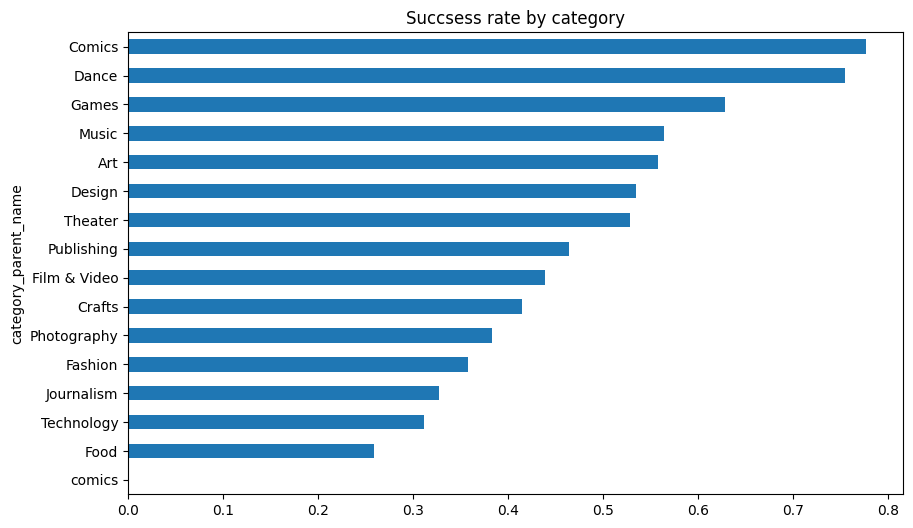

In [ ]:
# Exploratory Data Analysis
# success rate by category

success_by_cat = kick_df.groupby(
    'category_parent_name'
)['success'].mean().sort_values()

success_by_cat.plot(kind='barh', figsize=(10,6))
plt.title("Succsess rate by category")
plt.show()

In [ ]:
kick_df['title_length'] = kick_df['name'].apply(len)

kick_df['blurb_length'] = kick_df['blurb'].apply(len)

kick_df['text'] = (
    kick_df['name'] + " " +
    kick_df['blurb'] + " " +
    kick_df['profile_blurb']
)

X_cat = kick_df['text']

y_cat = kick_df['category_parent_name']

In [ ]:
features_success = [
    'goal_usd',
    'campaign_duration',
    'title_length',
    'blurb_length'
]

X_success = kick_df[features_success]

y_success = kick_df['success']

In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_success,
    y_success,
    test_size=0.2,
    random_state=42
)

In [ ]:
success_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    n_jobs=-1
)

In [ ]:
success_model.fit(X_train_s, y_train_s)

RandomForestClassifier(max_depth=20, n_estimators=300, n_jobs=-1)

In [ ]:
pred = success_model.predict(X_test_s)

print(classification_report(y_test_s, pred))

              precision    recall  f1-score   support

           0       0.62      0.59      0.61     51083
           1       0.60      0.64      0.62     49940

    accuracy                           0.61    101023
   macro avg       0.61      0.61      0.61    101023
weighted avg       0.61      0.61      0.61    101023



In [ ]:
goal_df = kick_df[kick_df['success']==1]

In [ ]:
features_goal = [
    'campaign_duration',
    'title_length',
    'blurb_length'
]

X_goal = goal_df[features_goal]

y_goal = goal_df['goal_usd']

In [ ]:
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_goal,
    y_goal,
    test_size=0.2,
    random_state=42
)

In [ ]:
goal_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    n_jobs=-1
)

In [ ]:
goal_model.fit(X_train_g, y_train_g)

RandomForestRegressor(max_depth=20, n_estimators=300, n_jobs=-1)

In [ ]:
pred = goal_model.predict(X_test_g)

print("MAE:", mean_absolute_error(y_test_g, pred))

MAE: 8955.144577297307
